# Stock Data Modelling using Random Walks and Geometric Brownian Motion
- GBM is the continuous limit of random walks

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


sns.set_style('darkgrid')

## Symmetric Random Walks
The $1$-step symmetric random walk, denoted by $W$, is probability distribution
$$W \sim \begin{cases} 1 & p = 1/2 \\ -1 & p = 1/2 \end{cases}$$

Note that
- $E[W] = 1/2 -1/2 = 0$
- $Var(W) = E[W^2] - E[W]^2 = 1/2 + 1/2 - 0 = 1$

The $n$-step symmetric random walk, denometed by $M_n$ is the probability distribution
$$ M_n \sim \sum_{i = 1}^n W_i$$
where $W_1, \dots, W_n$ are independent and equivalent to $W$.

Note that 
- $E[M_n] = n E[W] = 0$
- $Var(M_n) = n Var(W) = n$

**Application of the Central Limit Theorem**
$$ \lim_{n \to \infty} \frac{M_n - E[M_n]}{STD(M_n)} = \frac{M_n}{\sqrt{n}}  = \mathcal{N}(0,1)$$

**Alternative description** 
A useful alternative point of view of a randomw walk is flipping a fair coin $n$ times. Let $H_n$ denote the number of heads and the number of tails to be $T_n$. Then
$$M_n \sim H_n - T_n$$


## Risk-Free $n$-step random walk model of stock paths
- Risk free means the expectation value of returns is 1


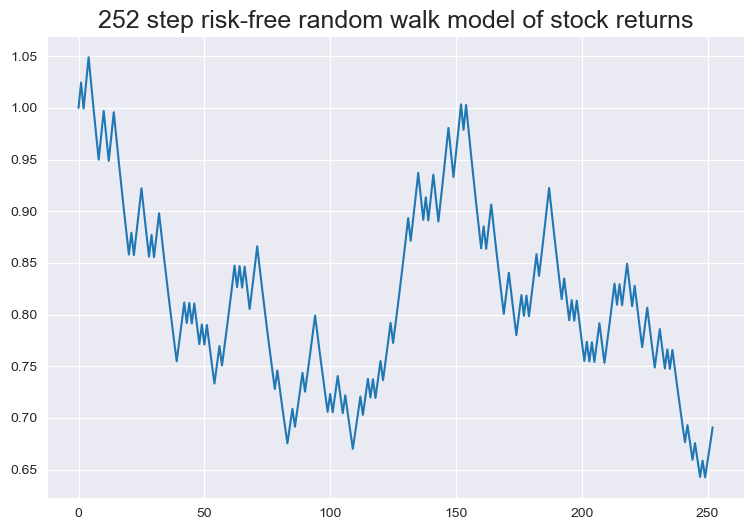

In [8]:
#Model stock returns as a random walk

#t_1 = 0

#t_2 = t>0

sigma = .3889

t = 1

n_steps = 252

dt = t/n_steps




ups = np.cumsum(np.random.choice([1,0], size = n_steps)) #1=Heads 0=Tails 

downs = np.arange(1,n_steps+1) - ups

stock_returns = ((1+sigma*np.sqrt(dt))**ups)*((1-sigma*np.sqrt(dt))**downs)

stock_returns = np.insert(stock_returns, 0, 1)

plt.figure(figsize = (9,6))

plt.plot(stock_returns)
plt.title(f'{n_steps} step risk-free random walk model of stock returns', size = 18)
plt.show()

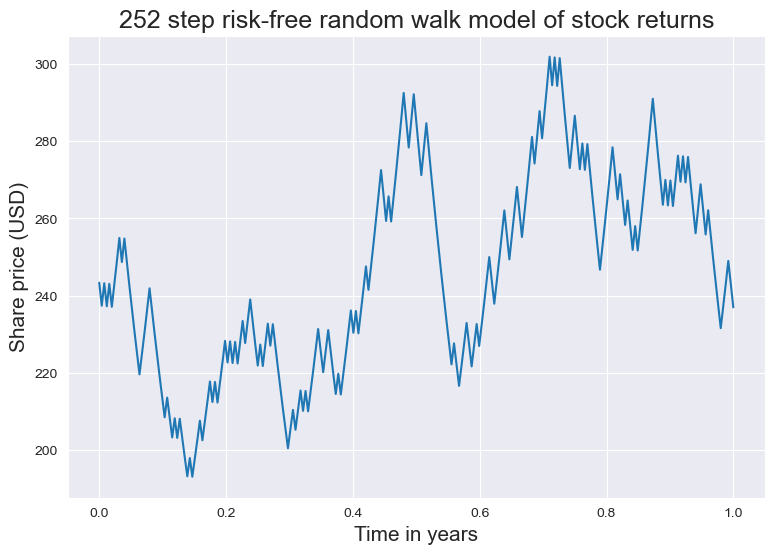

In [4]:
#Model stock path as a random walk

#t_1 = 0

#t_2 = t>0

S0 = 243.32 #Initial stock price

sigma = .3889

t = 1

n_steps = 252

dt = t/n_steps




ups = np.cumsum(np.random.choice([1,0], size = n_steps)) #1=Heads 0=Tails 

downs = np.arange(1,n_steps+1) - ups

stock_returns = ((1+sigma*np.sqrt(dt))**ups)*((1-sigma*np.sqrt(dt))**downs)

stock_returns = np.insert(stock_returns, 0, 1)

times = np.linspace(0,1, n_steps + 1)

plt.figure(figsize = (9,6))

plt.plot(times, S0*stock_returns)
plt.title(f'{n_steps} step risk-free random walk model of stock returns', size = 18)

plt.xlabel('Time in years', size = 15)

plt.ylabel('Share price (USD)', size = 15)
plt.show()

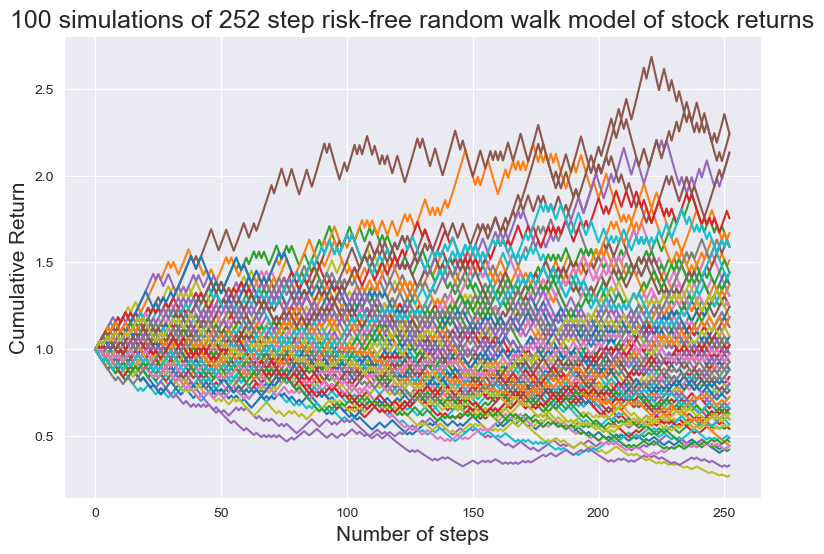

In [5]:
#Model stocks returns as random walk

#t_1 = 0

#t_2 = t>0

sigma = .3889

t = 1

n_steps = 252

n_sims = 100

dt = t/n_steps




ups = np.cumsum(np.random.choice([1,0], size = (n_sims,n_steps)), axis = 1) #1=Heads 0=Tails 

downs = np.arange(1,n_steps+1) - ups

stock_returns = ((1+sigma*np.sqrt(dt))**ups)*((1-sigma*np.sqrt(dt))**downs)

stock_returns = np.insert(stock_returns, 0, 1, axis = 1)

plt.figure(figsize = (9,6))
for stock_return_path in stock_returns:
    plt.plot(stock_return_path)
    
plt.title(f'{n_sims} simulations of {n_steps} step risk-free random walk model of stock returns', size = 18)

plt.xlabel('Number of steps', size = 15)
plt.ylabel('Cumulative Return', size = 15)
plt.show()

In [6]:
##Extremely fast random generation of 100000 stock paths with 252 steps each

import time

start = time.perf_counter()

sigma = .3889

t = 1

n_steps = 252

n_sims = 100000

dt = t/n_steps




ups = np.cumsum(np.random.choice([1,0], size = (n_sims,n_steps)), axis = 1) #1=Heads 0=Tails 

downs = np.arange(1,n_steps+1) - ups

stock_returns = ((1+sigma*np.sqrt(dt))**ups)*((1-sigma*np.sqrt(dt))**downs)

stock_returns = np.insert(stock_returns, 0, 1, axis = 1)


# code you want to time
result = sum(i**2 for i in range(10_000_000))

end = time.perf_counter()

print(f"Time needed to produce {n_sims} simulated stock returns with {n_steps} each: {end - start:.6f} seconds.")

Time needed to produce 100000 simulated stock returns with 252 each: 1.650013 seconds.


## Stock Paths as Geometric Brownian Motions
**Modelling Asuumption**: Fix a constant volatility $\sigma > 0$. If $t_1 < t_2$ are times, $S_{t_1}$ and $S_{t_2}$ are the distribution of stock prices of a stock $S$ at corresponding times. The limit as $n\to \infty$ of the $n$-step risk-free (expectation value of $1$) random walk model of the return is,
$$\frac{S_{t_2}}{S_{t_1}} = \lim_{n\to \infty} \prod_{i = 1}^n \frac{S_{t_1 + i dt_n}}{S_{t_1 + (i-1) dt_n}} = e^{-\frac{\sigma^2}{2} (t_2 - t_1) + \sigma \sqrt{t_2 - t_1} \mathcal{N}(0,1)}$$

The normal distribution in the exponent is the Wiener process that generates noise

**Alternative approach** The same outcome is reached if we model the discrete time steps by fixing a constant standard deviation of log-returns:
$$\frac{S_{t_2}}{S_{t_1}} = \lim_{n\to\infty}\left(e^{\sigma \sqrt{dt_n} H_n}\right)\left(e^{-\sigma \sqrt{dt_n} T_n}\right) = e^{-\frac{\sigma^2}{2} (t_2 - t_1) + \sigma \sqrt{t_2 - t_1} \mathcal{N}(0,1)}$$
We can see it by ataylor expansion of the exponentials in the limit

## $n$-step Geometric Brownian Motion model
Now let every small interval undergo this continuous GBM
$$\frac{S_{t_2}}{S_{t_1}} = \prod_{i = 1}^n \left(\text{GBM}_i\right)$$


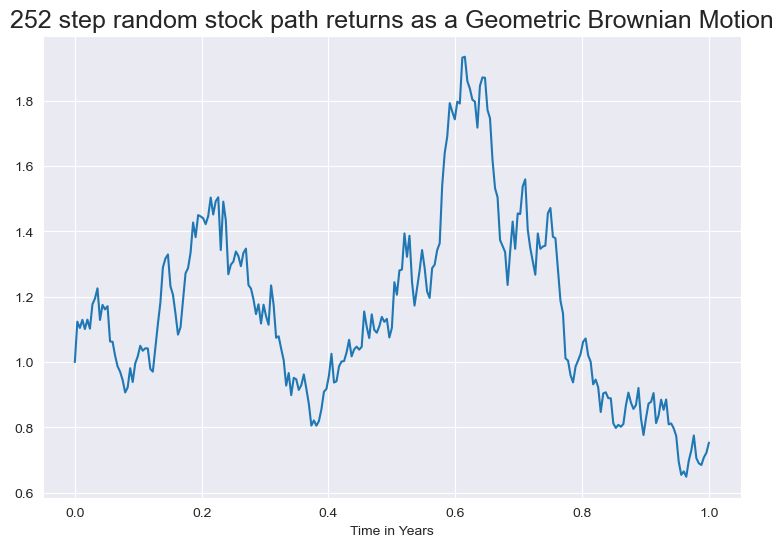

In [7]:
## Model stocks as GBM

sigma = .75

t = 1

n_steps = 252

dt = t/n_steps

noise = np.random.normal(size = n_steps)

log_returns = (-sigma**2)*(0.5)*dt + sigma*np.sqrt(dt)*noise

cum_log_returns = np.cumsum(log_returns) # product of returns is sum in log space

cum_log_returns = np.insert(cum_log_returns, 0, 0)

stock_returns = np.exp(cum_log_returns)

times = np.linspace(0,t, n_steps + 1)
plt.figure(figsize = (9,6))

plt.plot(times, stock_returns)
plt.title(f'{n_steps} step random stock path returns as a Geometric Brownian Motion', size = 18)

plt.xlabel('Time in Years')
plt.show()

- Exponential makes it non-negative

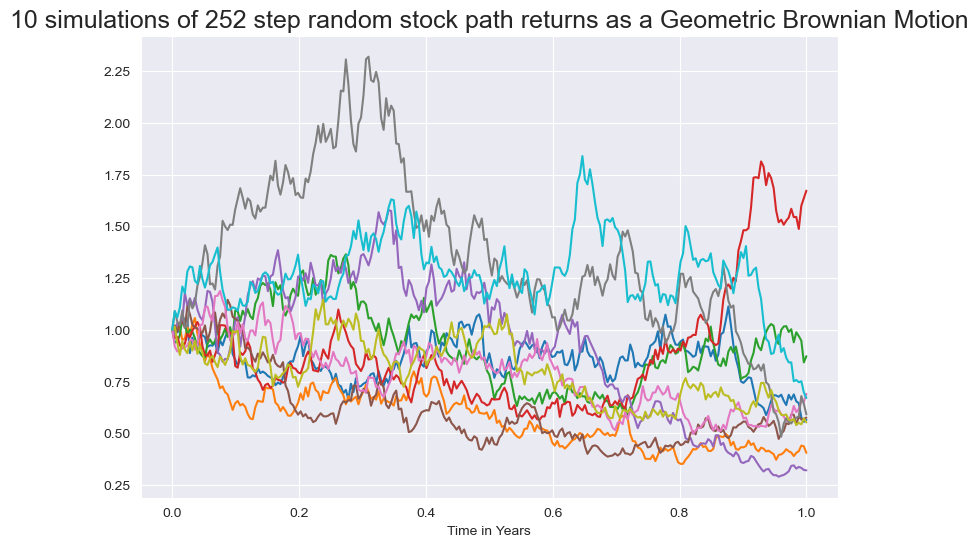

In [9]:
## Model stock returns as GBM

sigma = .75

t = 1

n_steps = 252

n_sims = 10

dt = t/n_steps

noise = np.random.normal(size = (n_sims, n_steps))

log_returns = (-sigma**2)*(0.5)*dt + sigma*np.sqrt(dt)*noise

cum_log_returns = np.cumsum(log_returns, axis = 1)

cum_log_returns = np.insert(cum_log_returns, 0, 0, axis = 1)

stock_returns = np.exp(cum_log_returns)

times = np.linspace(0,t, n_steps + 1)
plt.figure(figsize = (9,6))

for stock in stock_returns:
    plt.plot(times, stock)


    
plt.title(f'{n_sims} simulations of {n_steps} step random stock path returns as a Geometric Brownian Motion', size = 18)

plt.xlabel('Time in Years')
plt.show()

## Make 15 GBM simulations of google stock share price and compare it to the actual one

[*********************100%***********************]  1 of 1 completed


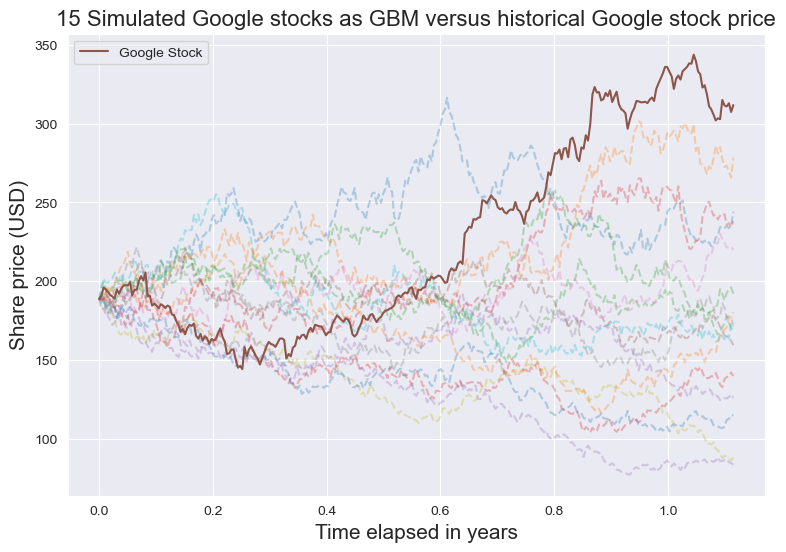

In [13]:
import yfinance as yf

stock_data = yf.download('GOOGL', start = '2025-01-01')

stock_prices = stock_data['Close']['GOOGL']

sigma = np.log(1+stock_prices.pct_change()).std()*np.sqrt(252)

S0 = stock_prices.iloc[0]

t = 281/252

n_steps = 288

n_sims = 15

dt = t/n_steps

noise = np.random.normal(size = (n_sims, n_steps))

log_returns = (-sigma**2*(0.5))*dt + sigma*np.sqrt(dt)*noise

cum_log_returns = np.cumsum(log_returns, axis = 1)

cum_log_returns = np.insert(cum_log_returns, 0, 0, axis = 1)

stock_path = S0*np.exp(cum_log_returns)


plt.figure(figsize = (9,6))

times = np.linspace(0,t, n_steps + 1)

for path in stock_path:
    plt.plot(times, path, alpha = .3, ls = '--')

plt.plot(times, stock_prices, label = 'Google Stock')
plt.title(f'{n_sims} Simulated Google stocks as GBM versus historical Google stock price', size = 16)


plt.legend()
plt.ylabel('Share price (USD)', size = 15)
plt.xlabel('Time elapsed in years', size = 15)
plt.show()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(15, 288))

### Imagine there is no noise, only volatility

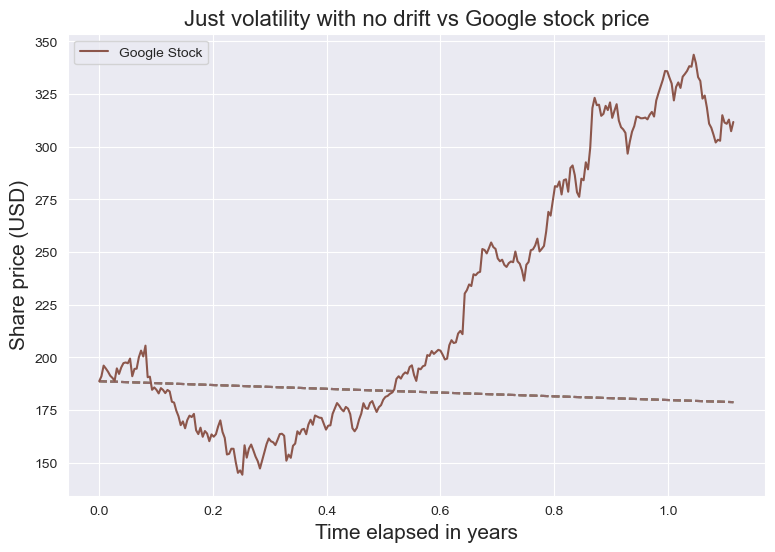

In [19]:
nonoise = np.zeros((n_sims,n_steps))

log_returns2 = (-sigma**2*(0.5))*dt + sigma*np.sqrt(dt)*nonoise

cum_log_returns2 = np.cumsum(log_returns2, axis = 1)

cum_log_returns2 = np.insert(cum_log_returns2, 0, 0, axis = 1)

stock_path2 = S0*np.exp(cum_log_returns2)


plt.figure(figsize = (9,6))

times = np.linspace(0,t, n_steps + 1)

for path in stock_path2:
    plt.plot(times, path, alpha = .3, ls = '--')

plt.plot(times, stock_prices, label = 'Google Stock')
plt.title(f'Just volatility with no drift vs Google stock price', size = 16)


plt.legend()
plt.ylabel('Share price (USD)', size = 15)
plt.xlabel('Time elapsed in years', size = 15)
plt.show()

- Volatility eats your returns in the long run!